Roll No: 24BAD112
Name: SIVASAKTHI S
Training model with sgd optimizer...
Training model with momentum optimizer...
Training model with rmsprop optimizer...
Training model with adam optimizer...


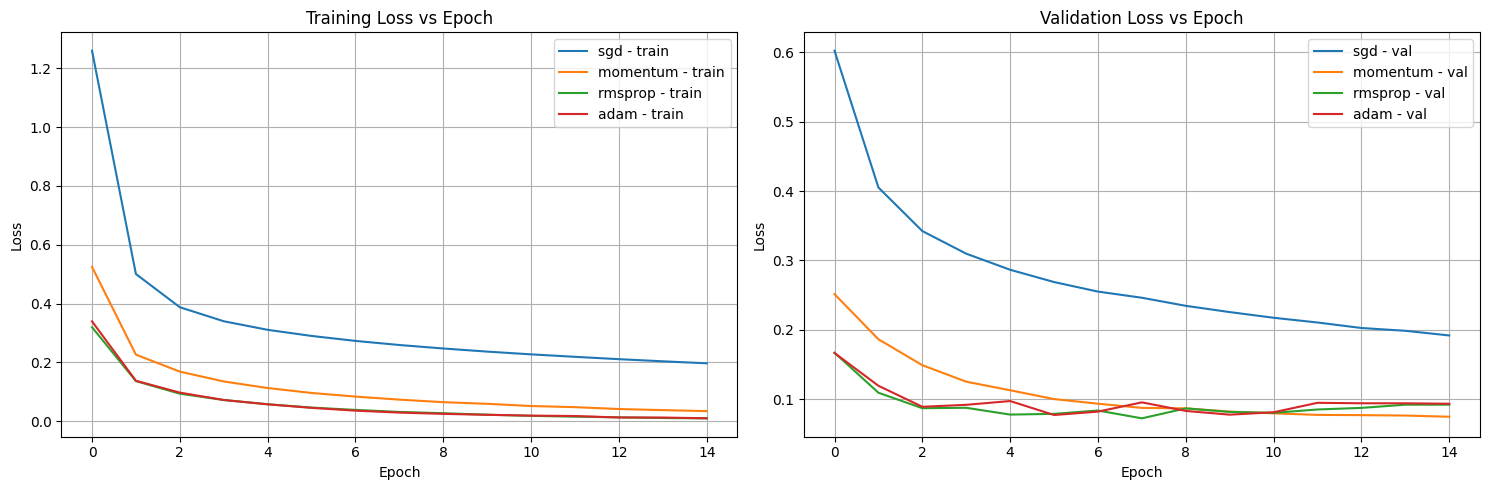

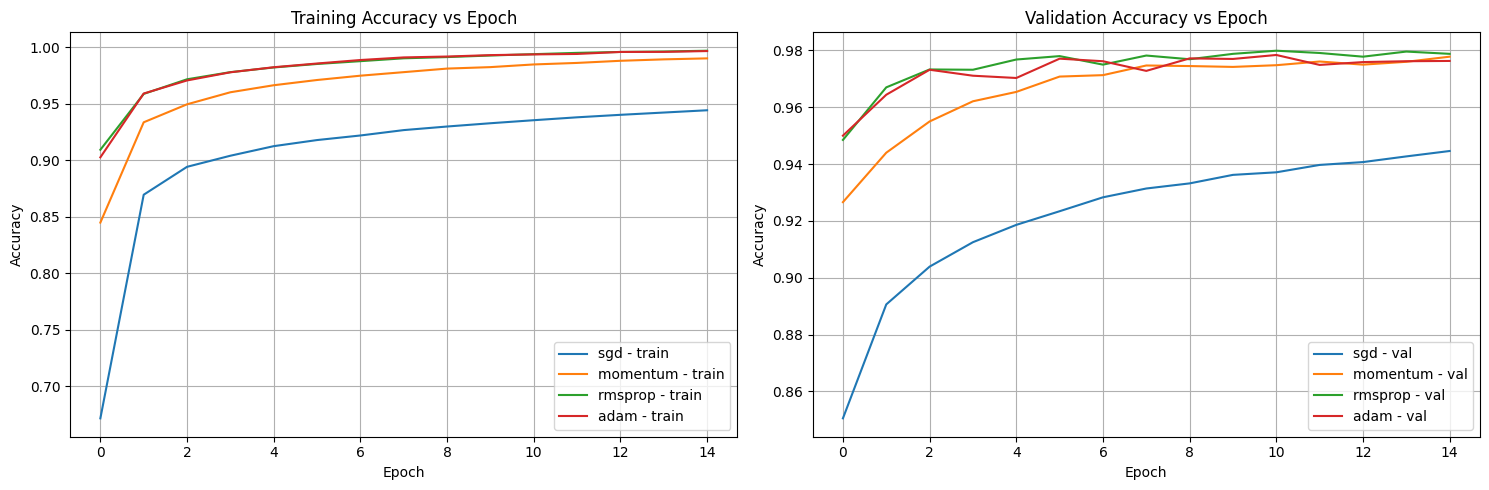


Final Performance Comparison
------------------------------------------------------------------------------------------
Optimizer   Train Acc   Val Acc     Train Loss  Val Loss    
------------------------------------------------------------------------------------------
sgd         0.9445      0.9446      0.1970      0.1917      
momentum    0.9904      0.9778      0.0345      0.0745      
rmsprop     0.9972      0.9788      0.0100      0.0919      
adam        0.9969      0.9763      0.0101      0.0932      


In [ ]:
print("Roll No: 24BAD112")
print("Name: SIVASAKTHI S")
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test = x_test.reshape(-1, 784).astype('float32') / 255.0
def build_and_train(optimizer_name, epochs=15):
    model = keras.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')])
    if optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=0.01)
    elif optimizer_name == 'momentum':
        opt = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=0.001)
    elif optimizer_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=0.001)
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    history = model.fit(x_train, y_train,
                         validation_data=(x_test, y_test),
                         epochs=epochs,
                         batch_size=128,
                         verbose=0)
    return history

optimizers = ['sgd', 'momentum', 'rmsprop', 'adam']
histories = {}
for opt_name in optimizers:
    print(f"Training model with {opt_name} optimizer...")
    histories[opt_name] = build_and_train(opt_name)

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for opt_name in optimizers:
    plt.plot(histories[opt_name].history['loss'], label=f'{opt_name} - train')
plt.title('Training Loss vs Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for opt_name in optimizers:
    plt.plot(histories[opt_name].history['val_loss'], label=f'{opt_name} - val')
plt.title('Validation Loss vs Epoch')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
for opt_name in optimizers:
    plt.plot(histories[opt_name].history['accuracy'], label=f'{opt_name} - train')
plt.title('Training Accuracy vs Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.subplot(1, 2, 2)
for opt_name in optimizers:
    plt.plot(histories[opt_name].history['val_accuracy'], label=f'{opt_name} - val')
plt.title('Validation Accuracy vs Epoch')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()


print("\nFinal Performance Comparison")
print("-" * 90)
print(f"{'Optimizer':<12}{'Train Acc':<12}{'Val Acc':<12}{'Train Loss':<12}{'Val Loss':<12}")
print("-" * 90)
for opt_name in optimizers:
    h = histories[opt_name].history
    print(f"{opt_name:<12}{h['accuracy'][-1]:<12.4f}{h['val_accuracy'][-1]:<12.4f}"
          f"{h['loss'][-1]:<12.4f}{h['val_loss'][-1]:<12.4f}")